
# **Lançes livres na NBA**

Vídeos ilustrativos:

[Lançes livres - Shaquille O'Neal](https://youtube.com/shorts/2CVZuRgqpWQ?si=zY_bT2LXnG3FoqNM)

[Lançes livres - Steve Nash](https://youtube.com/shorts/t1utDH8piq4?si=5Rme3lT89jNQASt3)

#Modelagem matemática

O objetivo é **caracterizar lançes livres "perfeitos"**.

##Simplificações do modelo



* Considerar apenas lançes que não tocam no aro ou na tabela
* Considerar somente os lançes totalmente alinhados com o centro do aro
* Desprezar a resistência do ar, considerando apenas o efeito da gravidade
* Desprezar a rotação da bola

Aplicar a teoria de lançamento de projéteis: **trajetórias parabólicas**.

Na seguinte figura temos uma representação esquemática da geometria do problema modelado indicando os parâmetros correspondentes. Ela mostra o plano vertical contendo o centro da bola e o centro do aro.

Os seguintes parâmetros estão associados com a configuração geométrica do modelo:

$L$ - distância entre as projeções horizontais do ponto de saída da bola e do centro do aro,

$H_a$ - altura do aro,

$D_a$ - diâmetro do aro,

$D_b$ - diâmetro da bola.

Os parâmetros relacionados à mecânica do arremesso são:

 $H_l$ - altura donde a bola é arremesssada,

 $v_0$ - velocidade inicial da bola,

 $\vartheta$ - ângulo do lançamento.

 **Figura**: Representação esquemática dos parâmetros do modelo.

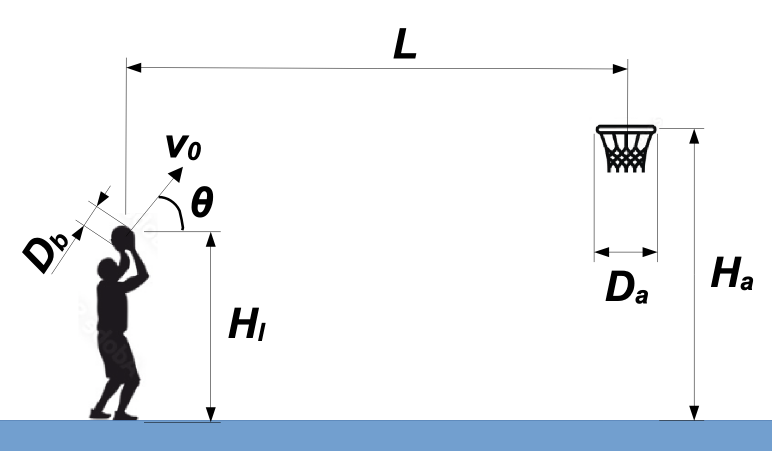


##Lançamento de um projétil

As equações que descrevem a trajetória de um projétil, considerando que no momento inicial o mesmo se encontra na origem do sistema de coordenada, são dadas por:

$x(t) := X(t; \vartheta, v_0) = v_0 t \cos(\vartheta)$

$y(t) := Y(t; \vartheta, v_0) = v_0 t \sin(\vartheta) - \frac{1}{2} g t^2$

onde
* $x$ - coordenada horizontal,
* $y$ - coordenada vertical,
* $t$ - tempo,
* $v_0$ - velocidade inicial,
* $\vartheta$ - ângulo de lançamento.



##Dados e funções

In [ ]:
import math
import numpy as np
from scipy import optimize
import matplotlib.pyplot as plt

## Parâmetros
g = 9.81
L = 4.57
Da = 0.4572
Db = 0.24
Dr = (Da-Db)/2
Ha = 3.05
#####
# Depende do jogador, aqui consideramos a altura de lançamento reportada para o ex-jogador Shaquille O'Neal
Hl = 2.70

# Altura do aro com relação à altura de lançamento da bola
H = Ha-Hl

#Coordenadas do centro da bola
def fx(t, v, theta):
  return v*t*np.cos(theta)

def fy(t, v, theta):
  return v*t*np.sin(theta)-0.5*g*t**2

#Coordenadas da curva inferior que limita a faixa gerada pelo movimento da bola
def fxi(t, v, theta):
  return v*t*np.cos(theta)+0.5*Db*(v*np.sin(theta)-g*t)\
                  /np.sqrt(v**2 - 2*g*t*v*np.sin(theta) + (g*t)**2)

def fyi(t, v, theta):
  return v*t*np.sin(theta)-0.5*g*t**2-0.5*Db*v*np.cos(theta)\
                  /np.sqrt(v**2 - 2*g*t*v*np.sin(theta) + (g*t)**2)

#Coordenadas da curva superior que limita a faixa gerada pelo movimento da bola
def fxe(t, v, theta):
  return v*t*np.cos(theta)-0.5*Db*(v*np.sin(theta)-g*t)\
                  /np.sqrt(v**2 - 2*g*t*v*np.sin(theta) + (g*t)**2)

def fye(t, v, theta):
  return v*t*np.sin(theta)-0.5*g*t**2+0.5*Db*v*np.cos(theta)\
                  /np.sqrt(v**2 - 2*g*t*v*np.sin(theta) + (g*t)**2)

#Tempo de voo até um ponto com coordenada horizontal igual a x
def ftf(x, v, theta):
  return x/v/np.cos(theta)

#Velocidade inicial necessária para atingir o ponto com coordenadas (x,H)
#num lançamento com ângulo theta.
def fv(x, theta, H):
  return (x/np.cos(theta))*np.sqrt(0.5*g/(x*np.tan(theta) - H))


##Mostrando trajetórias: três casos básicos

Vamos começar analisando três casos básicos de arremessos com regiões alvos específicas para a entrada da bola.

1.   A bola entra tocando na borda frontal do aro
2.   A bola entra passando pelo centro do aro
3.   A bola entra tocando a borda posterior do aro

Nesses casos, as coordenadas do centro da bola ao entrar no aro são dadas por
1.   $(x,y) = (x_f,H)$ com $x_f = L - \Delta R$;
2.   $(x,y) = (x_c,H)$ com $x_c = L$;
3.   $(x,y) = (x_p,H)$ com $x_p = L + \Delta R$;

em que $\Delta R = R_a -R_b = \frac{D_a -D_b}{2}$.

A fig. 1 mostra a vista lateral da posição da bola entrando no aro, para os três casos escolhidos, e a fig. 2 mostra a vista superior.  

As trajetórias associadas a cada caso estão ligadas por uma relação entre a velocidade inicial da bola e o ângulo do arremesso. No primeiro caso essa relação é obtida das equações:

$X(t;\vartheta, v_0) = x_f$,

$Y(t;\vartheta, v_0) = H$,

eliminando o tempo $t$.

Assim, da primeira equação obtemos que o tempo $t_f$ corrrespondente ao momento em que a bola atravessa o aro é dado por

$t_f = \frac{x_f}{v_0 \cos(\vartheta)}$,

substituindo $t=t_f$ na segunda equação obtemos que

$v_0\sin(\vartheta)\left( \frac{x_f}{v_0 \cos(\vartheta)}\right) - \frac{g}{2}\left( \frac{x_f}{v_0 \cos(\vartheta)}\right)^2 = H$

donde segue (**faça a conta no seu caderno!**)

$v_0 = \frac{x_f}{\cos(\vartheta)}\sqrt{{\frac{g}{2(x_f \tan(\vartheta) - H)}}}$.

Para obter as equações associadas com os outros casos é suficiente substituir $x_f$ por $x_c$ ou $x_p$ , segundo o caso.

No código abaixo usamos a biblioteca [Matplotlib](https://matplotlib.org/) para a visualização de gráficos.

**Fig. 1**

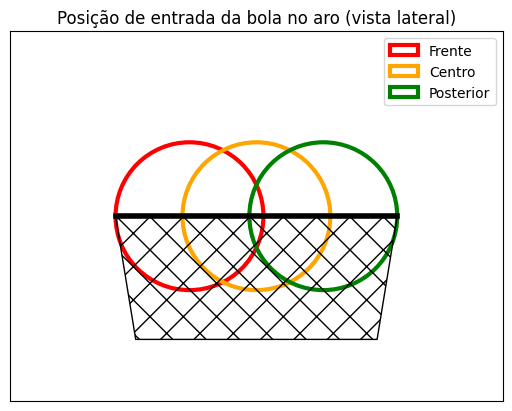


**Fig. 2**

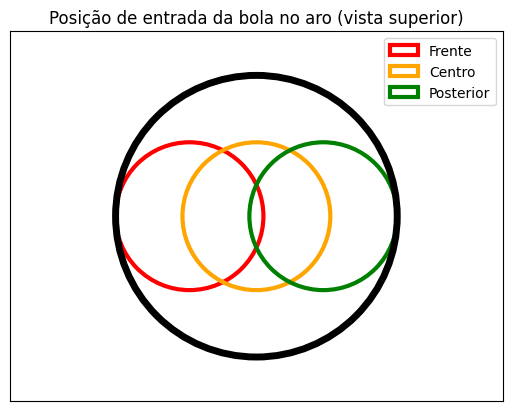


Frente
vel. min. 6.8800088975030205
ang. min. 47.160000000000004 

Centro
vel. min. 6.956760439071114
ang. min. 47.160000000000004 

Posterior
vel. min. 7.032697124677693
ang. min. 47.160000000000004 



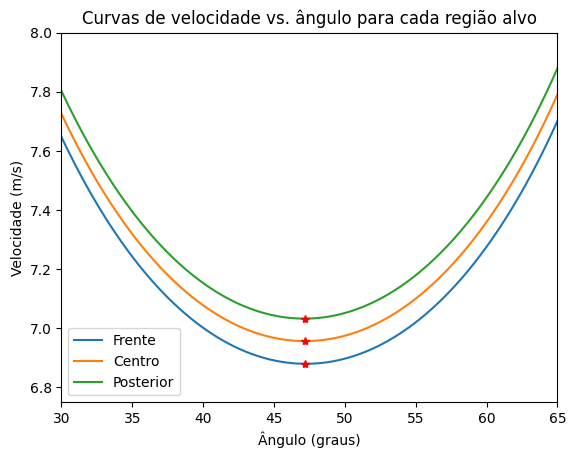

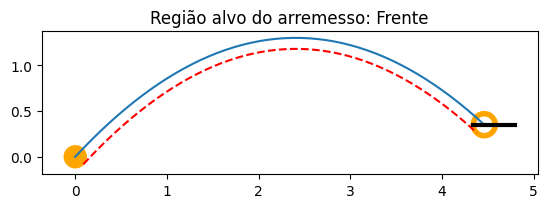

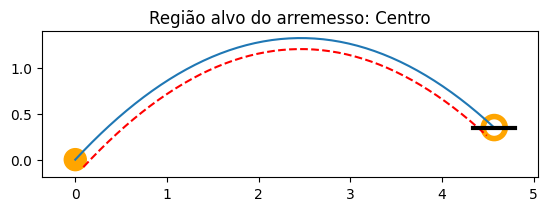

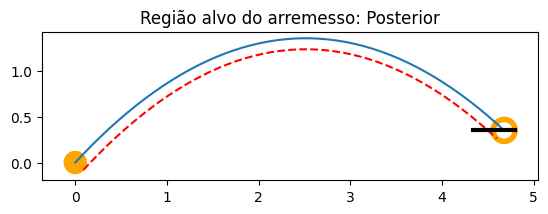

In [ ]:
import matplotlib.patches as patches

xs = np.linspace(L-Dr, L+Dr, num=3)

fig1, ax1 = plt.subplots()

ax=[]
labls = ['Frente', 'Centro', 'Posterior']

for i, x in enumerate(xs):
  ###
  theta = np.linspace(0,np.pi/2, num=500, endpoint=False)
  theta_0 = math.atan(2*H/x)
  theta_m = theta[theta > theta_0]
  v_m = fv(x, theta_m, H)

  v_min = np.min(v_m)
  theta_min = theta_m[v_m == v_min][0]
  print(labls[i])
  print("vel. min.", v_min)
  print("ang. min.", theta_min*180/np.pi,"\n")

  ax1.plot(theta_m*180/np.pi, v_m, label=labls[i])
  ax1.plot(theta_min*180/np.pi, v_min, '*r')
  ax1.set_xlim([30, 65])
  ax1.set_ylim([6.75, 8])
  ax1.set_xlabel("Ângulo (graus)")
  ax1.set_ylabel("Velocidade (m/s)")
  ax1.set_title("Curvas de velocidade vs. ângulo para cada região alvo")


  fig, ax = plt.subplots()
  tf = ftf(x, v_min, theta_min)
  t = np.linspace(0, tf, num=50)
  ax.plot(fx(t, v_min,theta_min), fy(t, v_min,theta_min))
  ax.set_title("Região alvo do arremesso: "+labls[i])

  ax.plot(fxi(t, v_min, theta_min), fyi(t, v_min, theta_min), 'r--')
  ax.plot([L-Da/2, L+Da/2], [H,H], '-k', lw=3)

  bola1 = patches.Circle((0, 0), radius=Db/2, color='orange', fill=True)
  ax.add_patch(bola1)
  bola2 = patches.Circle((x, H), radius=Db/2, color='orange', ls='-', lw=4, fill=False)
  ax.add_patch(bola2)
  ax.set_aspect('equal')

ax1.legend();

Na primeira figura gerada pelo código foram mostradas, para cada caso, as curvas da velocidade inicial quando o ângulo de lançamento varia. Também calculamos o ângulo associado com a velocidade mínima.

Vale destacar que toda a faixa de ângulos e velocidades limitada pelas curvas azul e vermelha caracterizam arremessos em que o centro da bola atravesaria o aro. Vamos chamá-la de região de arremessos admissíveis.

Nas outras três figuras mostramos as trajetórias da bola, para cada caso, quando o arremesso é realizado com a velocidade mínima.

Observamos que no primeiro caso a curva que descreve a parte inferior da faixa associada com a trajetória da bola não atravesa o aro. Isto indica que nesse arremesso a bola bate na parte frontal do aro!



#Arremessos "perfeitos"

##Eliminando os arremessos ruins: I

Para a bola não bater na parte frontal do aro, é necessário que a curva que descreve o contorno inferior da faixa gerada pelo movimento da bola atravesse o aro. Essa curva representa a envoltória inferior da família de circulos gerados pelo movimento da bola.

Para chegar na descrição desta envoltória, observamos na figura abaixo que num dado instante $t$, o ponto $P_i = (x_i(t),y_i(t))$ dessa curva coincide com o ponto da bola que se encontra mais longe da curva gerada pelo movimento do centro da bola. Representando o centro da bola como $C=(x(t), y(t))$ temos que o vetor
$\vec{CP_i} = R_b\, \mathbf{n}$ onde $\mathbf{n}$ é vetor normal à trajetória do centro da bola, ou seja é perpendicular ao vetor velocidade $\mathbf{v}(t) = (x'(t), y'(t))$. Assim, obtemos que

$\mathbf{n} = (y'(t), -x'(t))/v(t)$

onde $v(t) = \sqrt{(x'(t))^2 +(y'(t))^2}$, e chegamos em

$x_i(t) = x(t) + R_b \frac{y'(t)}{v(t)}$,

$y_i(t) = y(t) - R_b \frac{x'(t)}{v(t)}$.

Finalmente, para determinar se a bola não bateu no aro, fixando uma trajetória admissível da bola (ou seja, fixando os valores de $\vartheta$ e $v_0$) procuramos o ponto onde a envoltória intersecta a reta $y=H$ e decidimos se este ponto pertence ao aro ou não.

Desta forma precisamos achar $t_c$ da equação:

$y_i(t_c) = H$,

e testar se

$x_i(t_c) \in (L-R_a, L+R_a)$.

Na implementação abaixo percorremos as curvas de velocidade vs. ângulo associadas às trajetórias admissíveis, e escolhemos aqueles pontos da curva que passam no teste. Neste processo, para achar a solução aproximada da equação usamos a função [**root_scalar**](https://docs.scipy.org/doc/scipy-1.17.0/reference/generated/scipy.optimize.root_scalar.html#scipy.optimize.root_scalar) disponível na biblioteca [**Scipy**](https://scipy.org/).

**Figura**:

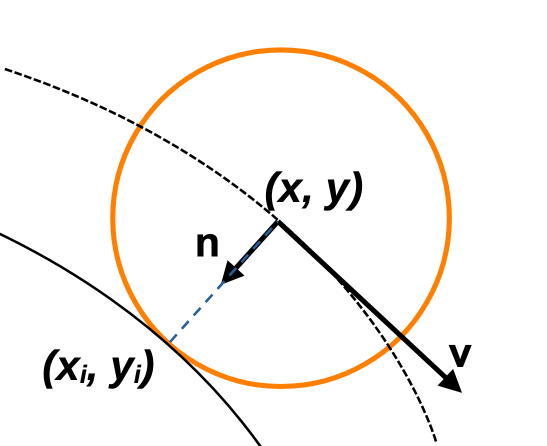

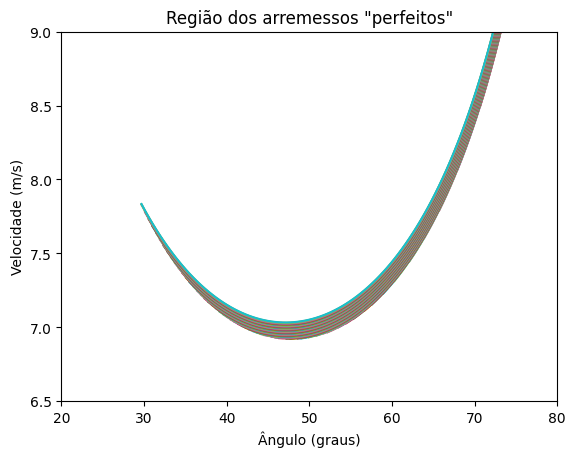

In [ ]:
xs = np.linspace(L-Dr, L+Dr, num=80)

fig1, ax1 = plt.subplots()

for x in xs:
  theta = np.linspace(0, np.pi/2, num=200, endpoint=False)
  theta_0 = math.atan(2*H/x)

  theta_m = theta[theta > theta_0]
  v_m = fv(x, theta_m, H)

  ## Selecionando os arremesos bons
  arrem_bom = []
  for theta, v in zip(theta_m, v_m):
    xxi = lambda t: fxi(t, v, theta)
    yyi = lambda t: fyi(t, v, theta)

    t_m = v*math.sin(theta)/g
    test_max = yyi(t_m) > H
    test_pos = False

    if test_max:
      tf = ftf(x, v, theta)
      ap_i = optimize.root_scalar(lambda t: yyi(t)-H, x0 = tf, xtol = 1e-5)
      t_i = ap_i.root
      test_pos = L-Da/2<xxi(t_i)

    arrem_bom.append(test_max and test_pos)

  arrem_bom = np.array(arrem_bom)
  theta_m = theta_m[arrem_bom == True]
  v_m = v_m[arrem_bom == True]

  if len(v_m) != 0:
    v_min = np.min(v_m)
    theta_min = theta_m[v_m == v_min][0]
    #print("Posição de entrada:", x)
    #print("vel. min.", v_min)
    #print("ang. min.", theta_min*180/np.pi)
    #print()

  ax1.plot(theta_m*180/np.pi, v_m)
  ax1.set_xlim([20, 80])
  ax1.set_ylim([6.5, 9])

  ax1.set_xlabel("Ângulo (graus)")
  ax1.set_ylabel("Velocidade (m/s)")
  ax1.set_title('Região dos arremessos "perfeitos"')

##Eliminando os arremessos ruins: II

Vamos apresentar uma forma mais eficiente de obter a região dos arremessos "perfeitos".

Para isto observamos que se para um ângulo e velocidade dados, a envoltória inferior encosta no aro no extremo frontal, quando aumentamos levemente o valor da velocidade temos um lançe que entrará no aro. Por tanto, a curva associada com esses ângulos e velocidades representa a borda inferior da região dos arremessos "perfeitos".

Para determinar essa curva observamos que

$x_i(t) := X_i(t; \vartheta, v_0)$ e $y_i(t) := Y_i(t; \vartheta, v_0)$

Por tanto eliminando $t$ das equações

$X_i(t; \vartheta, v_0) = L-R_a$

$Y_i(t; \vartheta, v_0) = H$

chegamos na relação desejada entre $\vartheta$ e $v_0$.

Na implementação que segue abaixo percorremos os ângulos e para cada valor do ângulo $\vartheta$ resolvemos as equações acima para obtermos os valores correspondentes de $v_0$ e $t$. A solução aproximada desse sistema de duas equações é obtida usando a função [**root**](https://docs.scipy.org/doc/scipy-1.17.0/reference/generated/scipy.optimize.root.html#scipy.optimize.root) disponível na biblioteca [**Scipy**](https://scipy.org/). Desta forma obtemos diretamente os pontos da curva de $v_0$ vs $\vartheta$.

Ponto limitrofe
ang. 29.25
vel. 7.882807791392743


Text(0.5, 1.0, 'Região dos arremessos "perfeitos"')

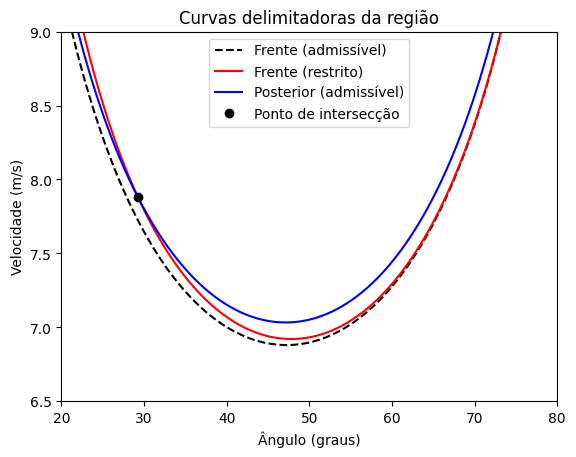

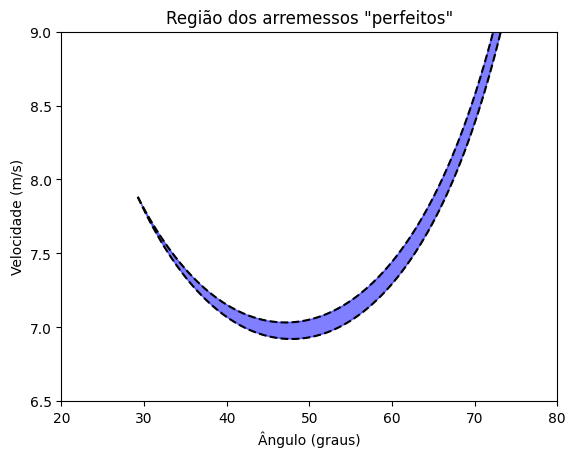

In [ ]:
def f1(t, v, theta):
  x1 = fxi(t, v, theta) - L + Da/2
  y1 = fyi(t, v, theta) - H

  return np.array([x1, y1])


thetas = np.linspace(0, np.pi/2, num=200, endpoint=False)

vs = []
ang_bons = []

Lp = L+Dr
Lf = L-Dr
theta_0 = math.atan(2*H/Lp)
theta_m = thetas[thetas > theta_0]
for theta in theta_m:
  v0 = 1
  t0 = ftf(L, v0, theta)

  fun = lambda x: f1(x[0], x[1], theta)
  sol = optimize.root( fun, [t0, v0])
  ang_bons.append(sol.success)
  vs.append(sol.x[1])

thetas1 = theta_m[np.array(ang_bons) == True]
vs1 = np.array(vs)
vs1 = vs1[np.array(ang_bons) == True]

theta_p = thetas[thetas > theta_0]
v_p = fv(Lp, theta_p, H)
v_f = fv(Lf, theta_p, H)

vs2 = v_p[np.array(ang_bons) == True]

idx = np.argmin(np.abs(vs1-vs2))

fig, ax = plt.subplots()
ax.plot(theta_p*180/np.pi, v_f, '--k', label='Frente (admissível)')
ax.plot(thetas1*180/np.pi, vs1, '-r', label='Frente (restrito)')
ax.plot(thetas1*180/np.pi, vs2, '-b', label='Posterior (admissível)')
ax.plot(thetas1[idx]*180/np.pi, vs1[idx], 'ok', label='Ponto de intersecção');

ax.set_xlim([20, 80])
ax.set_ylim([6.5, 9])
ax.set_xlabel("Ângulo (graus)")
ax.set_ylabel("Velocidade (m/s)")
ax.set_title('Curvas delimitadoras da região')
ax.legend()


fig1, ax1 = plt.subplots()
ax1.plot(thetas1[idx:]*180/np.pi, vs1[idx:], '--k', thetas1[idx:]*180/np.pi, vs2[idx:], '--k')
ax1.set_xlim([20, 80])
ax1.set_ylim([6.5, 9]);

ax1.fill_between(thetas1*180/np.pi, vs1, vs2, where= (vs1<vs2), color='blue', alpha=0.5);



print("Ponto limitrofe")
print("ang.", thetas1[idx]*180/np.pi)
print("vel.", vs1[idx])


ax1.set_xlabel("Ângulo (graus)")
ax1.set_ylabel("Velocidade (m/s)")
ax1.set_title('Região dos arremessos "perfeitos"')

##Eliminando os arremessos ruins: III

Vamos obter a região para arremessos ainda mais "perfeitos". Para isto eliminamos os lançes em que a bola encontas na parte posterior do aro.

A análise é analoga ao caso acima, mas considerando também a envoltória superior da faixa gerada pelo movimento da bola.

A envoltória superior é dada por

$x_e(t) = x(t) - R_b \frac{y'(t)}{v(t)}$,

$y_e(t) = y(t) + R_b \frac{x'(t)}{v(t)}$,

onde $v(t) = \sqrt{(x'(t))^2 +(y'(t))^2}$.
Nessas equações temos que
$x_e(t) := X_e(t; \vartheta, v_0)$ e $y_e(t) := Y_e(t; \vartheta, v_0)$



A implementação é baseada na solução das equações

$X_e(t; \vartheta, v_0) = L + R_a$

$Y_e(t; \vartheta, v_0) = H$

para cada ângulo $\vartheta$, e obtemos dessa forma a dependência entre $v_0$ e $\vartheta$.

Ponto limitrofe
ang. 37.800000000000004
vel. 7.170363446431556


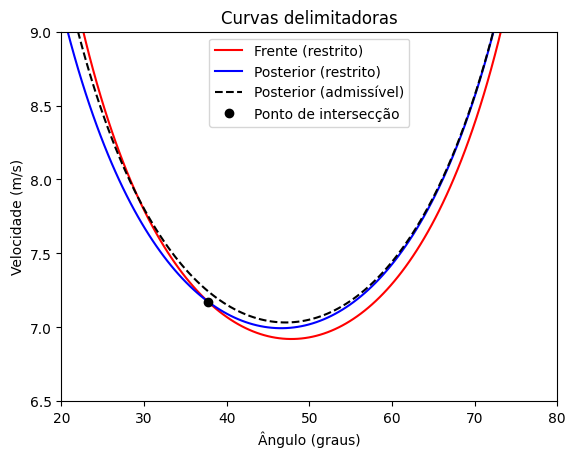

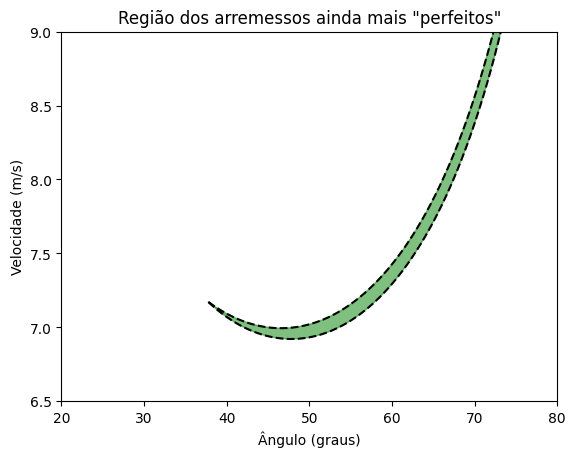

In [ ]:
def f1(t, v, theta):
  x1 = fxi(t, v, theta) - L + Da/2
  y1 = fyi(t, v, theta) - H

  return np.array([x1, y1])

def f2(t, v, theta):
  x2 = fxe(t, v, theta) - L - Da/2
  y2 = fye(t, v, theta) - H

  return np.array([x2, y2])

thetas = np.linspace(0, np.pi/2, num=200, endpoint=False)

vs_i = []
vs_e = []
ang_bons_i = []
ang_bons_e = []

Lp = L+Dr
theta_0 = math.atan(2*H/Lp)
theta_p = thetas[thetas > theta_0]

for theta in theta_p:
  v0 = 1
  t0 = ftf(L, v0, theta)

  fun_i = lambda x: f1(x[0], x[1], theta)
  sol_i = optimize.root( fun_i, [t0, v0])
  ang_bons_i.append(sol_i.success)
  vs_i.append(sol_i.x[1])

  fun_e = lambda x: f2(x[0], x[1], theta)
  sol_e = optimize.root( fun_e, [t0, v0])
  ang_bons_e.append(sol_e.success)
  vs_e.append(sol_e.x[1])


thetas1 = theta_p[np.array(ang_bons_i) == True]
vs1 = np.array(vs_i)
vs1 = vs1[np.array(ang_bons_i) == True]


thetas2 = theta_p[np.array(ang_bons_e) == True]
vs2 = np.array(vs_e)
vs2 = vs2[np.array(ang_bons_e) == True]

v_p = fv(Lp, theta_p, H)

#vs3 = v_m[np.array(ang_bons_i) == True]

idx = np.argmin(np.abs(vs1-vs2))

fig, ax = plt.subplots()
ax.plot(thetas1*180/np.pi, vs1, '-r', label='Frente (restrito)')
ax.plot(thetas2*180/np.pi, vs2, '-b', label='Posterior (restrito)')
ax.plot(theta_p*180/np.pi, v_p, '--k', label='Posterior (admissível)')
ax.plot(thetas1[idx]*180/np.pi, vs1[idx], 'ok', label='Ponto de intersecção');
ax.legend()

ax.set_xlim([20, 80])
ax.set_ylim([6.5, 9])
ax.set_xlabel("Ângulo (graus)")
ax.set_ylabel("Velocidade (m/s)")
ax.set_title('Curvas delimitadoras')

theta_l = thetas1[idx]
thetas_bom = thetas1[thetas1 >= theta_l]
vs1_bom = vs1[thetas1 >= theta_l]
vs2_bom = vs2[thetas2 >= theta_l]

fig1, ax1 = plt.subplots()
ax1.plot(thetas_bom*180/np.pi, vs1_bom, '--k', thetas_bom*180/np.pi, vs2_bom, '--k')
ax1.set_xlim([20, 80])
ax1.set_ylim([6.5, 9]);

ax1.fill_between(thetas_bom*180/np.pi, vs1_bom, vs2_bom, where= (vs1_bom<vs2_bom), color='green', alpha=0.5);


#ax1.plot(thetas1[idx]*180/np.pi, vs1[idx], '.k');


ax1.set_xlabel("Ângulo (graus)")
ax1.set_ylabel("Velocidade (m/s)")
ax1.set_title('Região dos arremessos ainda mais "perfeitos"')

print("Ponto limitrofe")
print("ang.", thetas1[idx]*180/np.pi)
print("vel.", vs1[idx])
